# Estadística descriptiva con Python y Jupyter

## Objetivo

Este notebook presenta un ejemplo completo de **estadística descriptiva** utilizando Python,
Pandas, NumPy, Matplotlib y Seaborn.

Trabajaremos con un conjunto de datos sintético relacionado con personas, incluyendo
variables demográficas, antropométricas, laborales y de hábitos de estudio.

### Conceptos tratados

- Tipos de variables.
- Frecuencias absolutas y relativas.
- Medidas de tendencia central.
- Medidas de dispersión.
- Percentiles y cuartiles.
- Rango intercuartílico.
- Coeficiente de variación.
- Asimetría y curtosis.
- Detección visual de valores atípicos.
- Histogramas.
- Boxplots.
- Gráficos de barras.
- Gráficos de dispersión.
- Matriz de correlaciones.
- Interpretación estadística.

> **Nota:** Los datos son sintéticos y se generan de forma reproducible mediante una semilla fija.

In [21]:
# Instalación opcional desde Jupyter si alguna biblioteca no está disponible:
# %pip install pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


## 1. Carga de los datos

El proyecto incluye un CSV inicial. Para que el notebook sea reproducible,
se utiliza el fichero `datos_estadistica_descriptiva.csv`.

Si se desea utilizar el notebook en otro directorio, basta con colocar el CSV
en la misma carpeta que el notebook.

In [22]:
from pathlib import Path
import pandas as pd

csv_file = Path("datos_estadistica_descriptiva.csv")

if not csv_file.exists():
    raise FileNotFoundError(
        f"No se encuentra {csv_file}. Coloca el CSV en la misma carpeta que el notebook."
    )

df = pd.read_csv(csv_file)

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
display(df.head())

Filas: 120
Columnas: 10


,id,edad,altura_m,peso_kg,imc,empleo,actividad_fisica,horas_estudio_semana,satisfaccion,ingresos_euros
0,1,22,1.61,59.1,22.8,Servicios,Baja,7.1,6,3023
1,2,55,1.80,92.5,28.5,Industria,Moderada,7.6,2,2141
2,3,49,1.53,59.6,25.5,Tecnología,Moderada,10.7,2,1630
3,4,39,1.67,71.1,25.5,Educación,Alta,1.6,6,2263
4,5,38,1.72,84.4,28.5,Educación,Moderada,3.9,2,2982


## 2. Conocer la estructura del conjunto de datos

Antes de calcular estadísticas debemos conocer:

- Número de observaciones.
- Número de variables.
- Tipo de cada variable.
- Posibles valores ausentes.

In [23]:
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
display(df.dtypes.to_frame("tipo"))

print("\nInformación general:")
df.info()

print("\nValores ausentes:")
display(df.isna().sum().to_frame("valores_ausentes"))

Dimensiones: (120, 10)

Tipos de datos:


,tipo
id,int64
edad,int64
altura_m,float64
peso_kg,float64
imc,float64
empleo,str
actividad_fisica,str
horas_estudio_semana,float64
satisfaccion,int64
ingresos_euros,int64



Información general:
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    120 non-null    int64  
 1   edad                  120 non-null    int64  
 2   altura_m              120 non-null    float64
 3   peso_kg               120 non-null    float64
 4   imc                   120 non-null    float64
 5   empleo                120 non-null    str    
 6   actividad_fisica      120 non-null    str    
 7   horas_estudio_semana  120 non-null    float64
 8   satisfaccion          120 non-null    int64  
 9   ingresos_euros        120 non-null    int64  
dtypes: float64(4), int64(4), str(2)
memory usage: 9.5 KB

Valores ausentes:


,valores_ausentes
id,0
edad,0
altura_m,0
peso_kg,0
imc,0
empleo,0
actividad_fisica,0
horas_estudio_semana,0
satisfaccion,0
ingresos_euros,0


## 3. Variables del dataset

| Variable | Tipo | Descripción |
|---|---|---|
| `id` | Cuantitativa discreta | Identificador |
| `edad` | Cuantitativa | Edad en años |
| `altura_m` | Cuantitativa continua | Altura en metros |
| `peso_kg` | Cuantitativa continua | Peso en kg |
| `imc` | Cuantitativa continua | Índice de masa corporal |
| `empleo` | Cualitativa nominal | Sector profesional |
| `actividad_fisica` | Cualitativa ordinal | Nivel de actividad |
| `horas_estudio_semana` | Cuantitativa continua | Horas de estudio |
| `satisfaccion` | Cuantitativa ordinal | Escala de 1 a 10 |
| `ingresos_euros` | Cuantitativa continua | Ingresos mensuales |

## 4. Estadística descriptiva básica

In [24]:
variables_numericas = [
    "edad", "altura_m", "peso_kg", "imc",
    "horas_estudio_semana", "satisfaccion", "ingresos_euros"
]

estadistica = df[variables_numericas].describe().T
estadistica["varianza"] = df[variables_numericas].var()
estadistica["asimetria"] = df[variables_numericas].skew()
estadistica["curtosis"] = df[variables_numericas].kurt()

display(estadistica.round(3))

,count,mean,std,min,25%,50%,75%,max,varianza,asimetria,curtosis
edad,120.0,42.442,13.150,18.00,31.000,42.50,54.250,64.00,172.921,-0.189,-1.196
altura_m,120.0,1.688,0.091,1.49,1.618,1.68,1.742,1.99,0.008,0.437,0.299
peso_kg,120.0,70.498,10.566,40.80,64.500,70.25,75.125,102.20,111.639,0.445,0.993
imc,120.0,24.666,2.568,16.80,22.800,24.60,26.300,31.10,6.594,0.025,0.103
horas_estudio_semana,120.0,7.928,3.296,1.00,5.775,7.80,10.100,16.30,10.864,0.042,-0.290
satisfaccion,120.0,5.408,2.909,1.00,3.000,5.00,8.000,10.00,8.462,0.169,-1.177
ingresos_euros,120.0,2309.133,608.262,1000.00,1799.000,2333.50,2727.250,3632.00,369982.234,-0.121,-0.589


## 5. Media, mediana y moda

Las medidas de tendencia central permiten identificar un valor representativo
de una distribución.

- **Media:** suma de los valores dividida entre el número de observaciones.
- **Mediana:** valor central después de ordenar los datos.
- **Moda:** valor o valores que aparecen con mayor frecuencia.

In [25]:
tendencia = pd.DataFrame({
    "media": df[variables_numericas].mean(),
    "mediana": df[variables_numericas].median(),
    "moda": df[variables_numericas].mode().iloc[0]
})

display(tendencia.round(3))

,media,mediana,moda
edad,42.442,42.50,55.00
altura_m,1.688,1.68,1.72
peso_kg,70.498,70.25,65.30
imc,24.666,24.60,24.60
horas_estudio_semana,7.928,7.80,6.90
satisfaccion,5.408,5.00,6.00
ingresos_euros,2309.133,2333.50,1000.00


## 6. Medidas de dispersión

La media por sí sola no describe completamente una distribución.

Calcularemos:

- Rango.
- Varianza.
- Desviación estándar.
- Rango intercuartílico.
- Coeficiente de variación.

El coeficiente de variación se calcula como:

\[
CV = \frac{\sigma}{\bar{x}}\times100
\]

y permite comparar la variabilidad relativa de variables que pueden estar
en escalas diferentes.

In [26]:
dispersion = pd.DataFrame(index=variables_numericas)

dispersion["mínimo"] = df[variables_numericas].min()
dispersion["máximo"] = df[variables_numericas].max()
dispersion["rango"] = dispersion["máximo"] - dispersion["mínimo"]
dispersion["varianza"] = df[variables_numericas].var()
dispersion["desviación_estándar"] = df[variables_numericas].std()
dispersion["Q1"] = df[variables_numericas].quantile(0.25)
dispersion["Q3"] = df[variables_numericas].quantile(0.75)
dispersion["IQR"] = dispersion["Q3"] - dispersion["Q1"]
dispersion["CV_%"] = (
    dispersion["desviación_estándar"] / df[variables_numericas].mean()
) * 100

display(dispersion.round(3))

,mínimo,máximo,rango,varianza,desviación_estándar,Q1,Q3,IQR,CV_%
edad,18.00,64.00,46.0,172.921,13.150,31.000,54.250,23.250,30.984
altura_m,1.49,1.99,0.5,0.008,0.091,1.618,1.742,0.125,5.387
peso_kg,40.80,102.20,61.4,111.639,10.566,64.500,75.125,10.625,14.987
imc,16.80,31.10,14.3,6.594,2.568,22.800,26.300,3.500,10.410
horas_estudio_semana,1.00,16.30,15.3,10.864,3.296,5.775,10.100,4.325,41.577
satisfaccion,1.00,10.00,9.0,8.462,2.909,3.000,8.000,5.000,53.787
ingresos_euros,1000.00,3632.00,2632.0,369982.234,608.262,1799.000,2727.250,928.250,26.342


## 7. Percentiles y cuartiles

Los percentiles dividen los datos ordenados en posiciones relativas.

Los cuartiles más utilizados son:

- Q1 = percentil 25.
- Q2 = percentil 50 = mediana.
- Q3 = percentil 75.

El rango intercuartílico es:

\[
IQR = Q_3-Q_1
\]

In [27]:
percentiles = df[variables_numericas].quantile([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
display(percentiles.round(3))

,edad,altura_m,peso_kg,imc,horas_estudio_semana,satisfaccion,ingresos_euros
0.05,21.95,1.560,54.495,20.795,2.100,1.0,1282.15
0.10,23.90,1.579,58.330,21.570,3.300,2.0,1508.10
0.25,31.00,1.618,64.500,22.800,5.775,3.0,1799.00
0.50,42.50,1.680,70.250,24.600,7.800,5.0,2333.50
0.75,54.25,1.742,75.125,26.300,10.100,8.0,2727.25
0.90,58.10,1.791,84.410,27.960,12.210,10.0,3041.40
0.95,61.05,1.850,87.645,29.110,13.215,10.0,3257.15


## 8. Frecuencias de variables categóricas

Para las variables cualitativas utilizamos frecuencias absolutas y relativas.

In [28]:
for variable in ["empleo", "actividad_fisica"]:
    print(f"\n### {variable}")
    frecuencia = df[variable].value_counts(dropna=False).to_frame("frecuencia")
    frecuencia["porcentaje"] = 100 * frecuencia["frecuencia"] / len(df)
    display(frecuencia.round(2))


### empleo


,frecuencia,porcentaje
empleo,,
Oficina,34,28.33
Servicios,26,21.67
Tecnología,24,20.00
Industria,18,15.00
Educación,18,15.00



### actividad_fisica


,frecuencia,porcentaje
actividad_fisica,,
Moderada,54,45.00
Alta,34,28.33
Baja,32,26.67


## 9. Gráfico de barras

Los gráficos de barras son apropiados para representar variables categóricas.

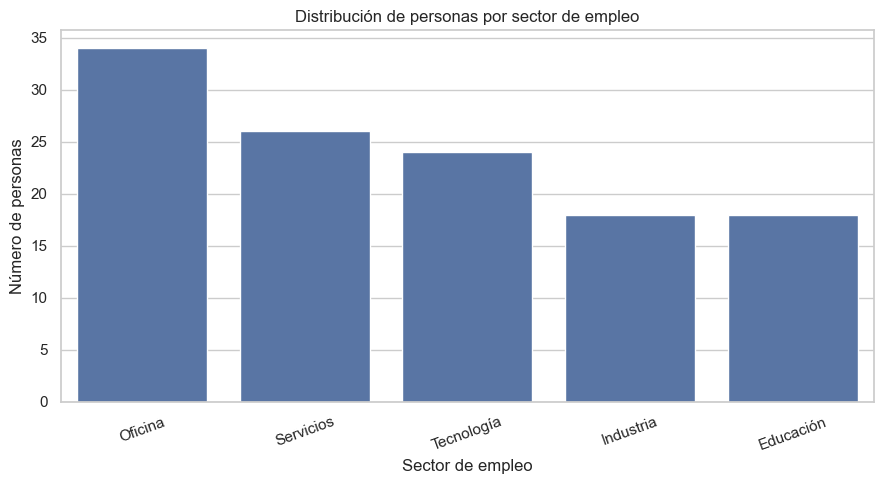

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 5))

orden = df["empleo"].value_counts().index
sns.countplot(
    data=df,
    x="empleo",
    order=orden,
    ax=ax
)

ax.set_title("Distribución de personas por sector de empleo")
ax.set_xlabel("Sector de empleo")
ax.set_ylabel("Número de personas")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 10. Histograma de la edad

Un histograma permite estudiar la forma de una distribución cuantitativa.

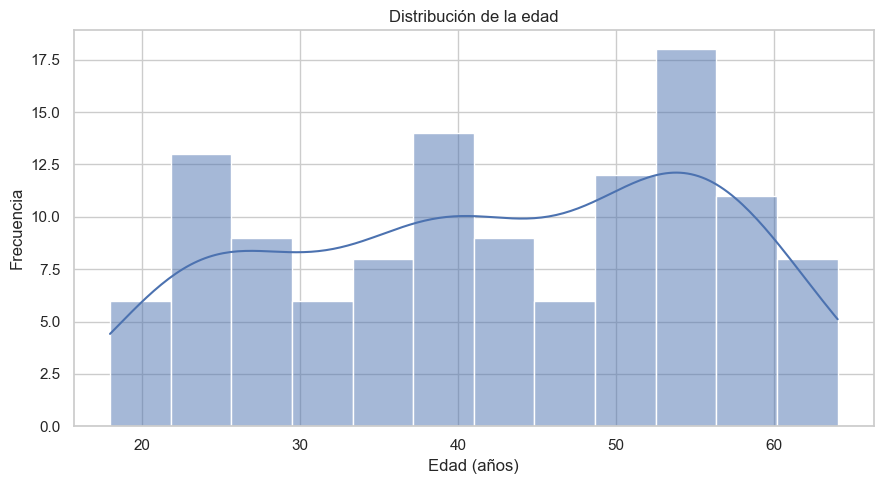

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df,
    x="edad",
    bins=12,
    kde=True,
    ax=ax
)

ax.set_title("Distribución de la edad")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 11. Histograma del IMC

El mismo procedimiento puede utilizarse para otras variables cuantitativas.

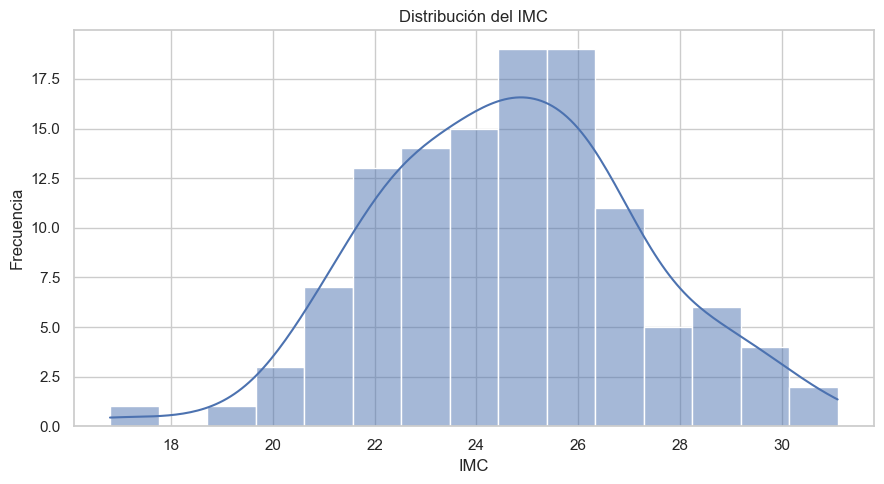

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df,
    x="imc",
    bins=15,
    kde=True,
    ax=ax
)

ax.set_title("Distribución del IMC")
ax.set_xlabel("IMC")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 12. Boxplot

El boxplot permite visualizar:

- Mediana.
- Primer y tercer cuartil.
- Rango intercuartílico.
- Posibles valores atípicos.

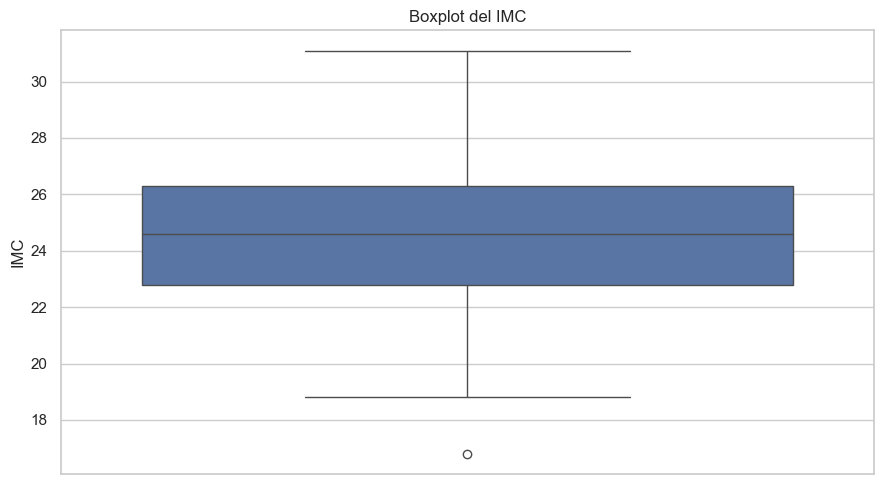

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df,
    y="imc",
    ax=ax
)

ax.set_title("Boxplot del IMC")
ax.set_ylabel("IMC")
plt.tight_layout()
plt.show()

## 13. Comparación de IMC según actividad física

Los boxplots permiten comparar la distribución de una variable cuantitativa
entre diferentes grupos.

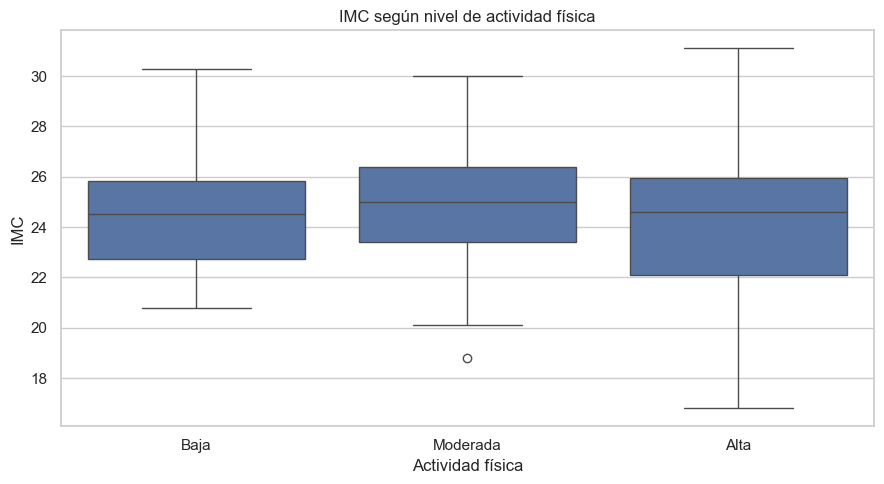

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="actividad_fisica",
    y="imc",
    order=["Baja", "Moderada", "Alta"],
    ax=ax
)

ax.set_title("IMC según nivel de actividad física")
ax.set_xlabel("Actividad física")
ax.set_ylabel("IMC")
plt.tight_layout()
plt.show()

## 14. Relación entre altura y peso

Un gráfico de dispersión permite observar visualmente la relación entre
dos variables cuantitativas.

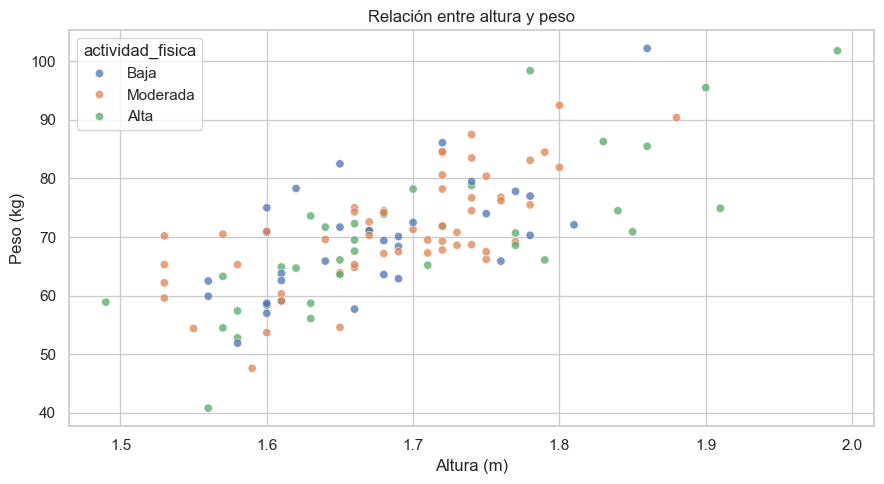

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="altura_m",
    y="peso_kg",
    hue="actividad_fisica",
    alpha=0.75,
    ax=ax
)

ax.set_title("Relación entre altura y peso")
ax.set_xlabel("Altura (m)")
ax.set_ylabel("Peso (kg)")
plt.tight_layout()
plt.show()

## 15. Correlación

El coeficiente de correlación de Pearson mide la intensidad y dirección de
una relación lineal entre dos variables cuantitativas.

Su valor se encuentra entre -1 y 1:

- próximo a 1: relación lineal positiva.
- próximo a -1: relación lineal negativa.
- próximo a 0: poca relación lineal.

In [35]:
correlaciones = df[variables_numericas].corr(method="pearson")
display(correlaciones.round(3))

,edad,altura_m,peso_kg,imc,horas_estudio_semana,satisfaccion,ingresos_euros
edad,1.000,0.044,0.213,0.268,-0.043,-0.101,-0.023
altura_m,0.044,1.000,0.723,-0.007,-0.164,0.032,-0.039
peso_kg,0.213,0.723,1.000,0.680,-0.222,0.069,-0.052
imc,0.268,-0.007,0.680,1.000,-0.150,0.039,-0.060
horas_estudio_semana,-0.043,-0.164,-0.222,-0.150,1.000,-0.032,-0.066
satisfaccion,-0.101,0.032,0.069,0.039,-0.032,1.000,-0.113
ingresos_euros,-0.023,-0.039,-0.052,-0.060,-0.066,-0.113,1.000


## 16. Mapa de calor de correlaciones

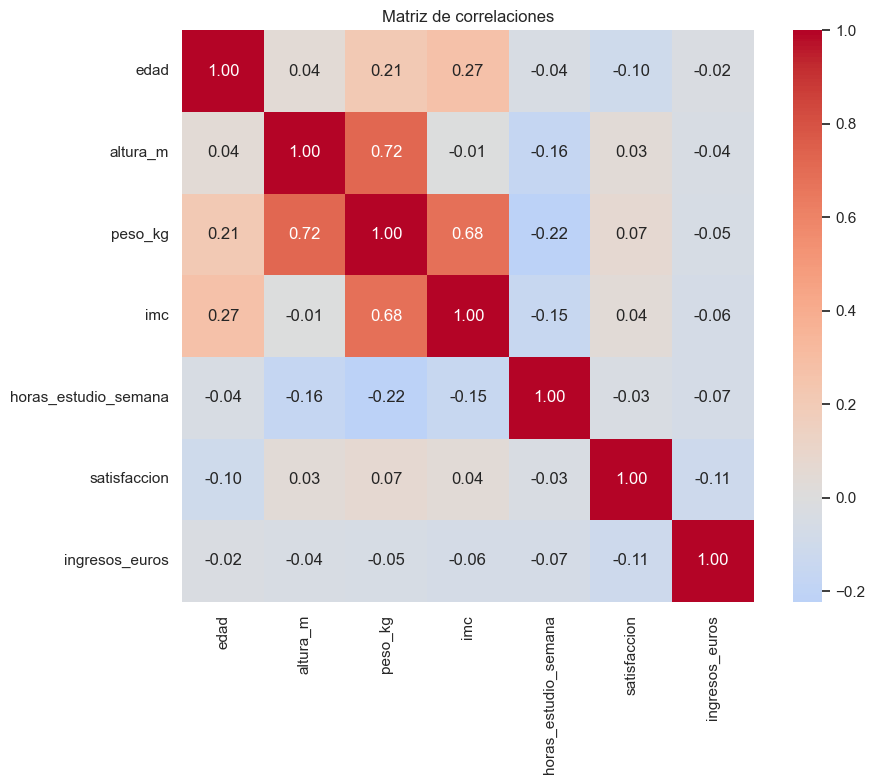

In [36]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    correlaciones,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax
)

ax.set_title("Matriz de correlaciones")
plt.tight_layout()
plt.show()

## 17. Asimetría y curtosis

La **asimetría** ayuda a identificar si una distribución está desplazada hacia
uno de sus extremos.

La **curtosis** describe el grado de concentración de los datos en torno al
centro y en sus colas respecto a una distribución de referencia.

Estos indicadores deben interpretarse conjuntamente con histogramas y boxplots.

In [37]:
forma = pd.DataFrame({
    "asimetría": df[variables_numericas].skew(),
    "curtosis": df[variables_numericas].kurt()
})

display(forma.round(3))

,asimetría,curtosis
edad,-0.189,-1.196
altura_m,0.437,0.299
peso_kg,0.445,0.993
imc,0.025,0.103
horas_estudio_semana,0.042,-0.290
satisfaccion,0.169,-1.177
ingresos_euros,-0.121,-0.589


## 18. Detección de posibles valores atípicos mediante IQR

Una regla habitual identifica como posibles valores atípicos aquellos que se
encuentran fuera del intervalo:

\[
[Q_1-1.5IQR,\; Q_3+1.5IQR]
\]

Esto no significa que todos los valores detectados sean errores: pueden ser
observaciones reales que requieren interpretación.

In [38]:
def detectar_outliers_iqr(dataframe, variable):
    q1 = dataframe[variable].quantile(0.25)
    q3 = dataframe[variable].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara = (
        (dataframe[variable] < limite_inferior) |
        (dataframe[variable] > limite_superior)
    )

    return dataframe[mascara], limite_inferior, limite_superior

for variable in ["edad", "peso_kg", "imc", "ingresos_euros"]:
    outliers, li, ls = detectar_outliers_iqr(df, variable)

    print(f"{variable}:")
    print(f"  Límite inferior: {li:.2f}")
    print(f"  Límite superior: {ls:.2f}")
    print(f"  Posibles outliers: {len(outliers)}")
    print()

edad:
  Límite inferior: -3.88
  Límite superior: 89.12
  Posibles outliers: 0

peso_kg:
  Límite inferior: 48.56
  Límite superior: 91.06
  Posibles outliers: 7

imc:
  Límite inferior: 17.55
  Límite superior: 31.55
  Posibles outliers: 1

ingresos_euros:
  Límite inferior: 406.62
  Límite superior: 4119.62
  Posibles outliers: 0



## 19. Resumen automático

Podemos construir un pequeño informe con las principales características
numéricas del dataset.

# 20. Ejercicios propuestos

### Ejercicio 1
Calcula la media, mediana, desviación estándar y rango del peso.

### Ejercicio 2
Determina qué sector de empleo tiene mayor frecuencia.

### Ejercicio 3
Representa mediante un histograma la distribución de los ingresos.

### Ejercicio 4
Realiza un boxplot de los ingresos e identifica posibles valores atípicos.

### Ejercicio 5
Calcula la correlación entre altura y peso. Interpreta el resultado.

### Ejercicio 6
Compara mediante boxplots el IMC de los tres niveles de actividad física.

### Ejercicio 7
Selecciona una variable cuantitativa y analiza conjuntamente:
media, mediana, desviación estándar, asimetría, histograma y boxplot.

### Ejercicio 8
Construye un informe estadístico de una página que incluya una tabla
descriptiva y al menos tres gráficos.

In [41]:
def resumen_variable(dataframe, variable):
    serie = dataframe[variable].dropna()

    media = serie.mean()
    mediana = serie.median()

    if media > mediana:
        tendencia = "media > mediana: posible asimetría positiva"
    elif media < mediana:
        tendencia = "media < mediana: posible asimetría negativa"
    else:
        tendencia = "media ≈ mediana"

    return {
        "variable": variable,
        "n": len(serie),
        "media": round(media, 3),
        "mediana": round(mediana, 3),
        "desv_std": round(serie.std(), 3),
        "mínimo": round(serie.min(), 3),
        "máximo": round(serie.max(), 3),
        "asimetría": round(serie.skew(), 3),
        "interpretación_media_mediana": tendencia
    }

resumen = pd.DataFrame(
    [resumen_variable(df, variable) for variable in variables_numericas]
)
display(resumen_variable(df, 'peso_kg'))
display(resumen)

{'variable': 'peso_kg',
 'n': 120,
 'media': np.float64(70.498),
 'mediana': np.float64(70.25),
 'desv_std': np.float64(10.566),
 'mínimo': np.float64(40.8),
 'máximo': np.float64(102.2),
 'asimetría': np.float64(0.445),
 'interpretación_media_mediana': 'media > mediana: posible asimetría positiva'}

,variable,n,media,mediana,desv_std,mínimo,máximo,asimetría,interpretación_media_mediana
0,edad,120,42.442,42.50,13.150,18.00,64.00,-0.189,media < mediana: posible asimetría negativa
1,altura_m,120,1.688,1.68,0.091,1.49,1.99,0.437,media > mediana: posible asimetría positiva
2,peso_kg,120,70.498,70.25,10.566,40.80,102.20,0.445,media > mediana: posible asimetría positiva
3,imc,120,24.666,24.60,2.568,16.80,31.10,0.025,media > mediana: posible asimetría positiva
4,horas_estudio_semana,120,7.928,7.80,3.296,1.00,16.30,0.042,media > mediana: posible asimetría positiva
5,satisfaccion,120,5.408,5.00,2.909,1.00,10.00,0.169,media > mediana: posible asimetría positiva
6,ingresos_euros,120,2309.133,2333.50,608.262,1000.00,3632.00,-0.121,media < mediana: posible asimetría negativa


# 21. Conclusiones

La estadística descriptiva constituye una etapa fundamental del análisis de
datos y del aprendizaje automático.

Antes de entrenar un modelo predictivo es recomendable:

1. Comprender las variables.
2. Comprobar tipos de datos y valores ausentes.
3. Analizar las distribuciones.
4. Detectar posibles valores atípicos.
5. Estudiar la variabilidad.
6. Analizar relaciones entre variables.
7. Visualizar los datos.

Este proceso permite detectar problemas de calidad y comprender la estructura
del conjunto de datos antes de aplicar técnicas estadísticas o de Machine Learning.

In [42]:
Calcula la media, mediana, desviación estándar y rango del peso.

SyntaxError: invalid syntax (751199848.py, line 1)

In [43]:
import pandas as pd

# Calcular métricas del peso
peso_media = df["peso_kg"].mean()
peso_mediana = df["peso_kg"].median()
peso_std = df["peso_kg"].std()
peso_rango = df["peso_kg"].max() - df["peso_kg"].min()

# Presentar resultados
resultados_peso = pd.Series({
    "Media": peso_media,
    "Mediana": peso_mediana,
    "Desviación Estándar": peso_std,
    "Rango": peso_rango
}, name="Métricas de Peso (kg)")

display(resultados_peso.to_frame())

,Métricas de Peso (kg)
Media,70.498333
Mediana,70.250000
Desviación Estándar,10.565919
Rango,61.400000


In [44]:
Representa mediante un histograma la distribución de los ingresos.

SyntaxError: invalid syntax (1196130518.py, line 1)

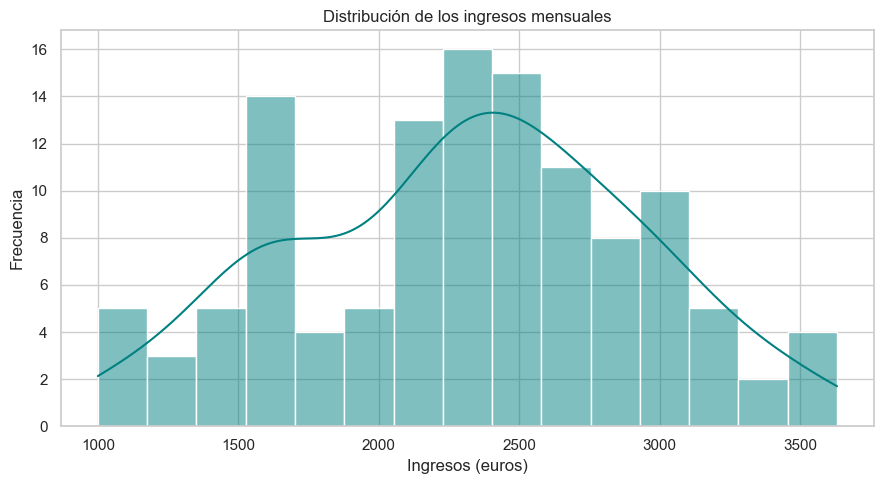

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear la figura para el histograma de ingresos
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df,
    x="ingresos_euros",
    bins=15,
    kde=True,
    color="teal",
    ax=ax
)

ax.set_title("Distribución de los ingresos mensuales")
ax.set_xlabel("Ingresos (euros)")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [46]:
Realiza un boxplot de los ingresos e identifica posibles valores atípicos

SyntaxError: invalid syntax (303492628.py, line 1)

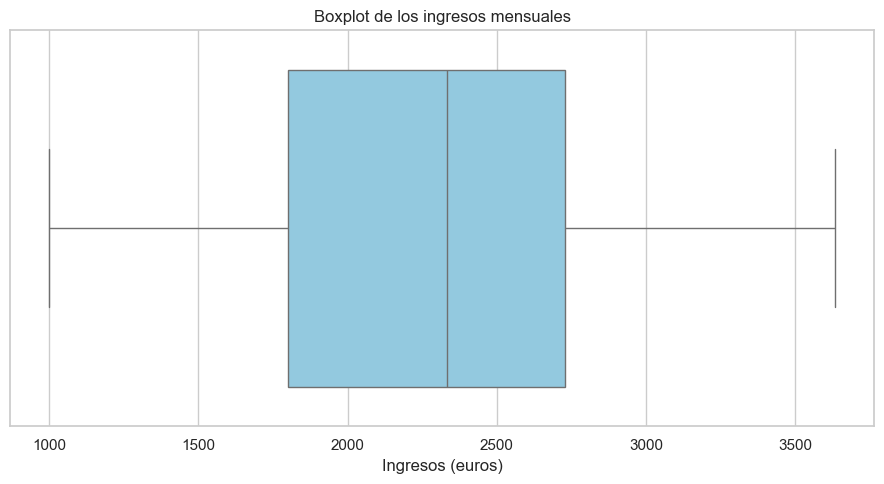

Resultados de la detección de atípicos para ingresos:
  Límite inferior (Q1 - 1.5*IQR): 406.62
  Límite superior (Q3 + 1.5*IQR): 4119.62
  Cantidad de posibles valores atípicos: 0


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crear el Boxplot de ingresos
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="ingresos_euros",
    color="skyblue",
    ax=ax
)

ax.set_title("Boxplot de los ingresos mensuales")
ax.set_xlabel("Ingresos (euros)")
plt.tight_layout()
plt.show()

# 2. Identificar y mostrar posibles valores atípicos mediante la regla IQR
outliers, li, ls = detectar_outliers_iqr(df, "ingresos_euros")

print("Resultados de la detección de atípicos para ingresos:")
print(f"  Límite inferior (Q1 - 1.5*IQR): {li:.2f}")
print(f"  Límite superior (Q3 + 1.5*IQR): {ls:.2f}")
print(f"  Cantidad de posibles valores atípicos: {len(outliers)}")
if len(outliers) > 0:
    display(outliers)

In [48]:
Calcula la correlación entre altura y peso. Interpreta el resultado.

SyntaxError: invalid syntax (3953937231.py, line 1)

In [49]:
# Calcular el coeficiente de correlación de Pearson entre altura y peso
correlacion = df['altura_m'].corr(df['peso_kg'])

print(f"Coeficiente de correlación de Pearson: {correlacion:.4f}")

# Interpretación del resultado
print("\nInterpretación:")
if correlacion > 0.7:
    print(f"Existe una correlación positiva fuerte ({correlacion:.2f}) entre la altura y el peso.")
    print("Esto indica que, a medida que la altura de una persona aumenta, su peso también tiende a incrementar de manera notable.")
elif correlacion > 0.3:
    print(f"Existe una correlación positiva moderada ({correlacion:.2f}) entre la altura y el peso.")
else:
    print(f"La correlación es débil o inexistente ({correlacion:.2f}) entre la altura y el peso.")

Coeficiente de correlación de Pearson: 0.7228

Interpretación:
Existe una correlación positiva fuerte (0.72) entre la altura y el peso.
Esto indica que, a medida que la altura de una persona aumenta, su peso también tiende a incrementar de manera notable.


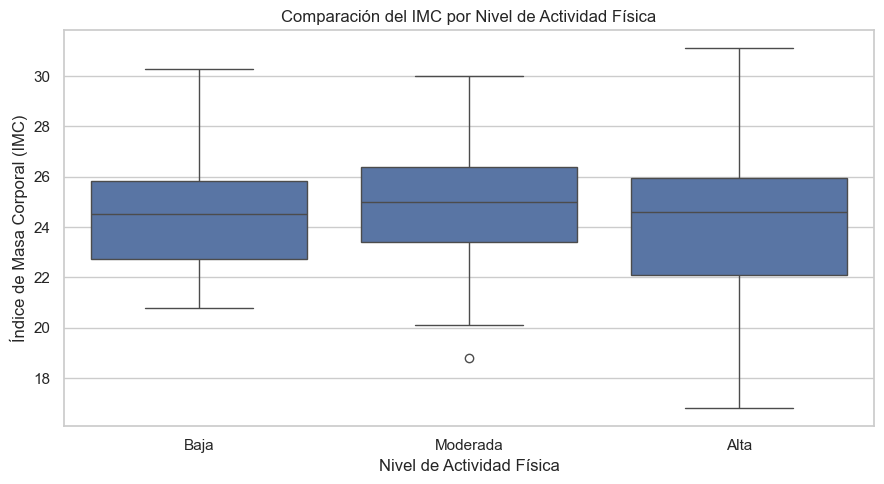

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear la figura para comparar el IMC según la actividad física
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="actividad_fisica",
    y="imc",
    order=["Baja", "Moderada", "Alta"],
    
    ax=ax
)

ax.set_title("Comparación del IMC por Nivel de Actividad Física")
ax.set_xlabel("Nivel de Actividad Física")
ax.set_ylabel("Índice de Masa Corporal (IMC)")

plt.tight_layout()
plt.show()

In [51]:
Compara mediante boxplots el IMC de los tres niveles de actividad física.

SyntaxError: invalid syntax (3813995883.py, line 1)

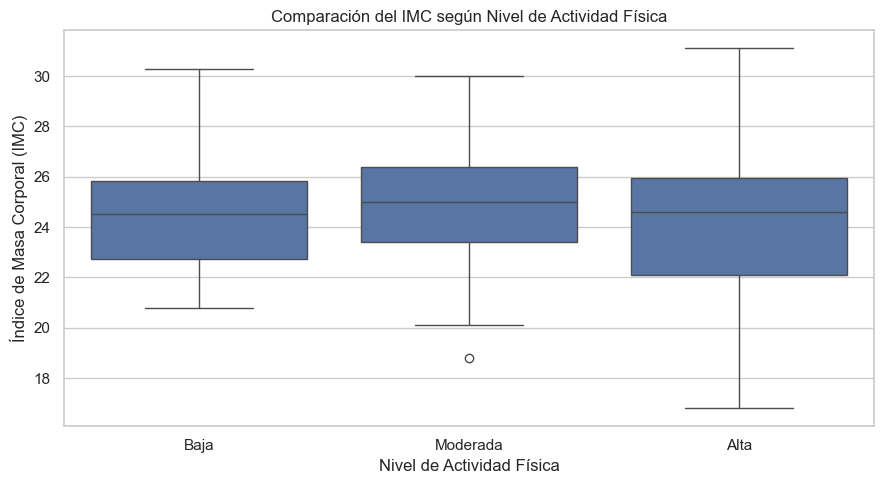

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear la comparación del IMC según actividad física
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="actividad_fisica",
    y="imc",
    order=["Baja", "Moderada", "Alta"],
    
    ax=ax
)

ax.set_title("Comparación del IMC según Nivel de Actividad Física")
ax.set_xlabel("Nivel de Actividad Física")
ax.set_ylabel("Índice de Masa Corporal (IMC)")
plt.tight_layout()
plt.show()

In [55]:
Selecciona una variable cuantitativa y analiza conjuntamente: media, mediana, desviación estándar, asimetría, histograma y boxplot.

SyntaxError: invalid syntax (366005814.py, line 1)

Análisis conjunto para la variable: 'horas_estudio_semana'
  Media: 7.928
  Mediana: 7.800
  Desviación Estándar: 3.296
  Asimetría (Skewness): 0.042


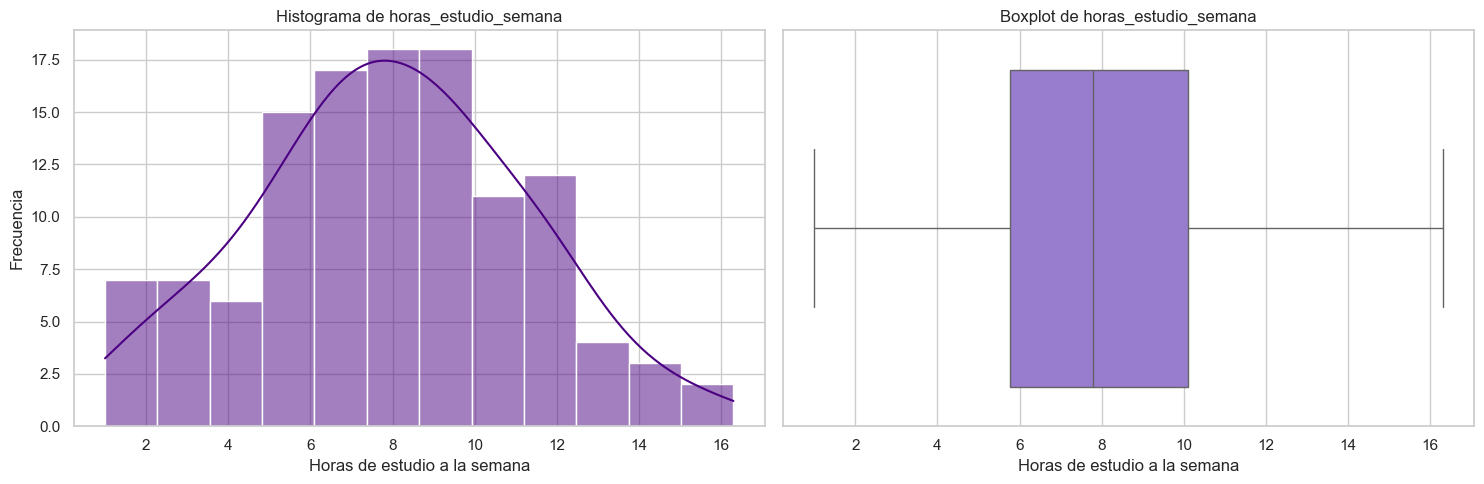

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

variable_sel = "horas_estudio_semana"

# 1. Calcular estadísticas descriptivas
media = df[variable_sel].mean()
mediana = df[variable_sel].median()
desv_std = df[variable_sel].std()
asimetria = df[variable_sel].skew()

print(f"Análisis conjunto para la variable: '{variable_sel}'")
print(f"  Media: {media:.3f}")
print(f"  Mediana: {mediana:.3f}")
print(f"  Desviación Estándar: {desv_std:.3f}")
print(f"  Asimetría (Skewness): {asimetria:.3f}")

# 2. Crear las visualizaciones (Histograma + Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma con KDE
sns.histplot(data=df, x=variable_sel, bins=12, kde=True, color="indigo", ax=axes[0])
axes[0].set_title(f"Histograma de {variable_sel}")
axes[0].set_xlabel("Horas de estudio a la semana")
axes[0].set_ylabel("Frecuencia")

# Boxplot
sns.boxplot(data=df, x=variable_sel, color="mediumpurple", ax=axes[1])
axes[1].set_title(f"Boxplot de {variable_sel}")
axes[1].set_xlabel("Horas de estudio a la semana")

plt.tight_layout()
plt.show()

Construye un informe estadístico de una página que incluya una tabla descriptiva y al menos tres gráficos.

                 INFORME ESTADÍSTICO DESCRIPTIVO                       

--- TABLA RESUMEN DE VARIABLES CLAVE ---


,Media,Mediana,Desv. Est.,Mínimo,Máximo
edad,42.44,42.50,13.15,18.0,64.0
peso_kg,70.50,70.25,10.57,40.8,102.2
imc,24.67,24.60,2.57,16.8,31.1
ingresos_euros,2309.13,2333.50,608.26,1000.0,3632.0


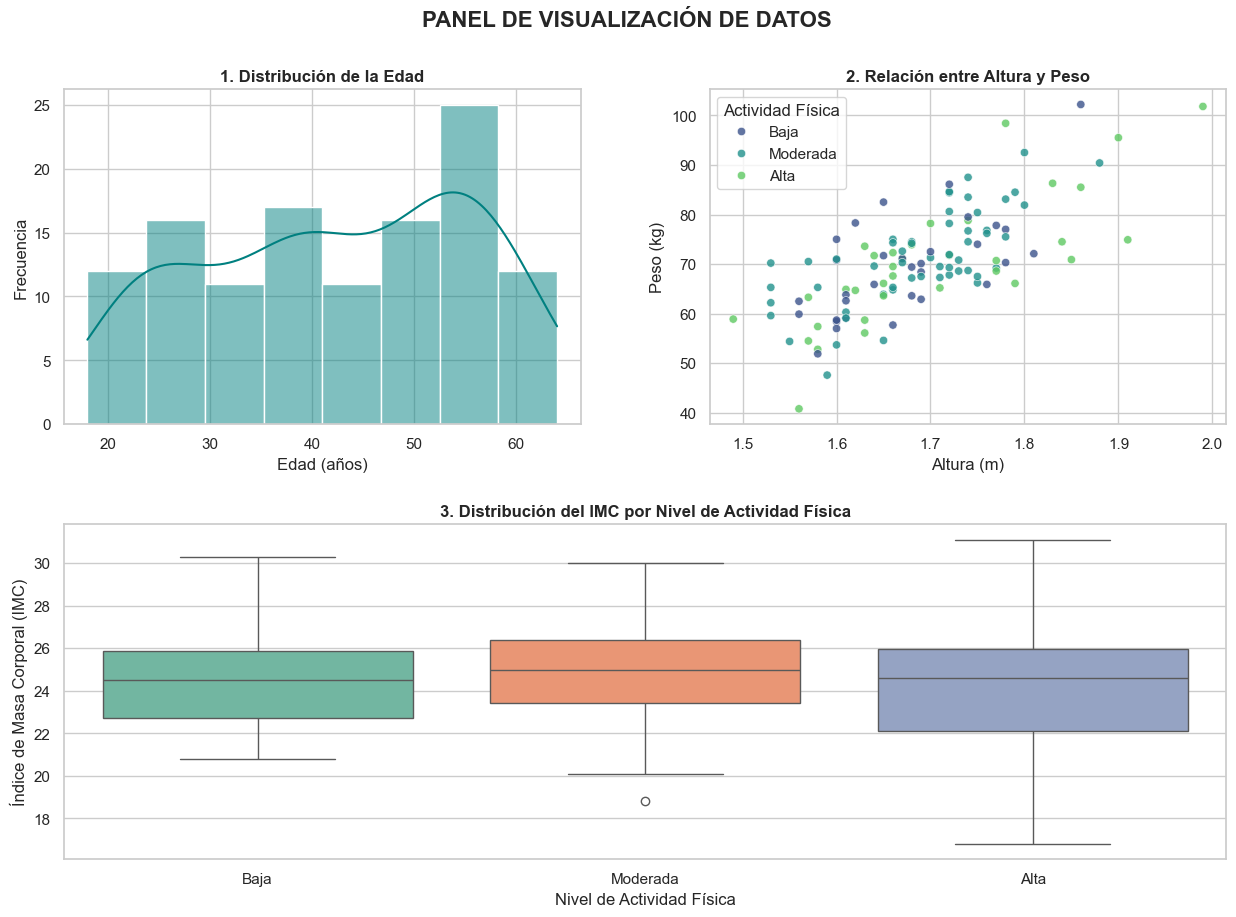

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Tabla descriptiva clave para el informe
variables_informe = ["edad", "peso_kg", "imc", "ingresos_euros"]
tabla_descriptiva = df[variables_informe].describe().T[["mean", "50%", "std", "min", "max"]]
tabla_descriptiva.columns = ["Media", "Mediana", "Desv. Est.", "Mínimo", "Máximo"]

print("=========================================================================")
print("                 INFORME ESTADÍSTICO DESCRIPTIVO                       ")
print("=========================================================================")
print("\n--- TABLA RESUMEN DE VARIABLES CLAVE ---")
display(tabla_descriptiva.round(2))

# 2. Diseño del panel gráfico (dashboard de una página con 3 gráficos)
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

# Gráfico 1: Distribución de la Edad (Histograma con KDE)
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(data=df, x="edad", kde=True, color="teal", ax=ax1)
ax1.set_title("1. Distribución de la Edad", fontsize=12, fontweight="bold")
ax1.set_xlabel("Edad (años)")
ax1.set_ylabel("Frecuencia")

# Gráfico 2: Relación entre Altura y Peso (Dispersión)
ax2 = fig.add_subplot(gs[0, 1])
sns.scatterplot(data=df, x="altura_m", y="peso_kg", hue="actividad_fisica", palette="viridis", alpha=0.8, ax=ax2)
ax2.set_title("2. Relación entre Altura y Peso", fontsize=12, fontweight="bold")
ax2.set_xlabel("Altura (m)")
ax2.set_ylabel("Peso (kg)")
ax2.legend(title="Actividad Física")

# Gráfico 3: Comparación de IMC según Nivel de Actividad Física (Boxplot)
ax3 = fig.add_subplot(gs[1, :])
sns.boxplot(data=df, x="actividad_fisica", y="imc", order=["Baja", "Moderada", "Alta"], palette="Set2", ax=ax3, hue="actividad_fisica", legend=False)
ax3.set_title("3. Distribución del IMC por Nivel de Actividad Física", fontsize=12, fontweight="bold")
ax3.set_xlabel("Nivel de Actividad Física")
ax3.set_ylabel("Índice de Masa Corporal (IMC)")

plt.suptitle("PANEL DE VISUALIZACIÓN DE DATOS", fontsize=16, fontweight="bold", y=0.96)
plt.show()